# Boosting

L'objectif est d'étudier les modèles de Boosting: comprendre leur fonctionnement et le choix des paramètres.

## 1 - Multiclass classification with Boosting

D'abord, on va s'intéresser à un dataset sur lequel on va diviser nos données en données de train et données de test. Le but ensuite est d'entraîner 3 modèles sur ces données, dont 2 modèles de Boosting, et de compareur leurs résultats et temps d'exécution.

In [1]:
from sklearn.datasets import fetch_covtype
X, y = fetch_covtype(return_X_y=True, as_frame=False)

In [2]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,y, 
                                    test_size=0.5, stratify=y)

In [3]:
from sklearn.ensemble import AdaBoostClassifier, HistGradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
clf = AdaBoostClassifier(DecisionTreeClassifier(max_depth=12), 
                        n_estimators=100)

In [4]:
hgb = HistGradientBoostingClassifier(max_iter=100, max_depth=5)

In [5]:
from sklearn.ensemble import RandomForestClassifier
forest = RandomForestClassifier()

**HistGradientBoostingClassifier**

In [6]:
from sklearn.metrics import accuracy_score
import time 
start = time.time()
hgb.fit(X_train, Y_train)
score_test_hgb = accuracy_score(Y_test, hgb.predict(X_test))
stop = time.time()
print(f"time: {stop-start}s")
print(f"score de test: {score_test_hgb}")

time: 6.500149488449097s
score de test: 0.800575547492995


**AdaBoostClassifier**

In [12]:
start = time.time()
clf.fit(X_train, Y_train)
score_test_clf = accuracy_score(Y_test, clf.predict(X_test))
stop = time.time()
print(f"time: {stop-start}s")
print(f"score de test: {score_test_clf}")

time: 257.34090304374695s
score de test: 0.8520099412748791


**RandomForestClassifier**

In [8]:
start = time.time()
forest.fit(X_train, Y_train)
score_test_forest = accuracy_score(Y_test, forest.predict(X_test))
stop = time.time()
print(f"time: {stop-start}s")
print(f"score de test: {score_test_forest}")

time: 51.213062047958374s
score de test: 0.944548477484114


Le modèle HistGradientBoosting s’avère rapide et donne des résultats satisfaisants. Pour ce jeu de données, le meilleur modèle est le RandomForest, car il entraîne les données en un temps raisonnable tout en obtenant un faible taux d’erreur de prédiction (~5 %).  

Concernant le modèle AdaBoost, avec une profondeur d’arbre de 3, on obtient un score d’environ 45 %, et avec une profondeur de 5, environ 55 %. Ces performances restent modestes, mais relativement correctes si l’on considère qu’il s’agit d’une classification à 7 classes et non d’un problème binaire. En revanche, en augmentant le nombre d’arbres à 12, le score de prédiction grimpe à environ 85 %, ce qui représente une nette amélioration. Cependant, cette hausse de performance s’accompagne d’un temps d’exécution beaucoup plus long.

## 2 - Depth of decision trees in Adaboost and Gradient Boosting

L'objectif désormais est de comparer les taux d'erreur obtenus par les deux modèles de Boosting en fonction dde la profondeur des arbres de décision. On testera ces deux modèles sur deux datasets.

In [49]:
from sklearn.datasets import fetch_openml
X,y = fetch_openml("car-evaluation", return_X_y=True, as_frame=False)

In [65]:
X_train, X_test, Y_train, Y_test = train_test_split(X,y, 
                                    test_size=0.5, stratify=y)

In [51]:
import numpy as np
erreurs = []
depths = np.arange(1,16)
max_depth = 15
for depth in range(1,max_depth+1):
    clf = AdaBoostClassifier(DecisionTreeClassifier(max_depth=depth), 
                            n_estimators=100)
    clf.fit(X_train, Y_train)
    score_test_clf = accuracy_score(Y_test, clf.predict(X_test))
    erreurs.append(1-score_test_clf)

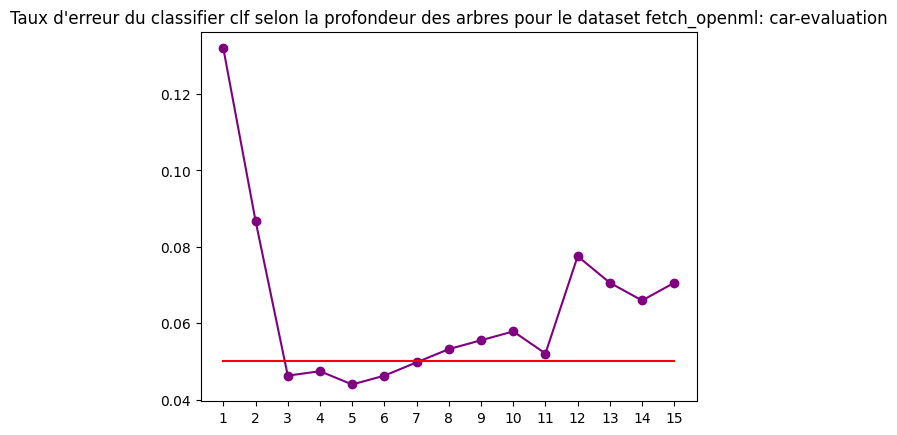

In [85]:
import matplotlib.pyplot as plt
plt.plot(depths, erreurs, '-o', color='purple')
plt.plot([1,15], [0.05,0.05], c='red')
plt.title("Taux d'erreur du classifier clf selon la profondeur des arbres pour le dataset fetch_openml: car-evaluation")
plt.xticks(np.arange(1,16))
plt.show()

On préfera choisir une profondeur maximal comprise entre 3 et 5 arbres.

In [66]:
import numpy as np
erreurs_hgb = []
depths = np.arange(1,16)
max_depth = 15
for depth in range(1,max_depth+1):
    hgb = HistGradientBoostingClassifier(max_iter=100, max_depth=depth)
    hgb.fit(X_train, Y_train)
    score_test_hgb = accuracy_score(Y_test, hgb.predict(X_test))
    erreurs_hgb.append(1-score_test_hgb)

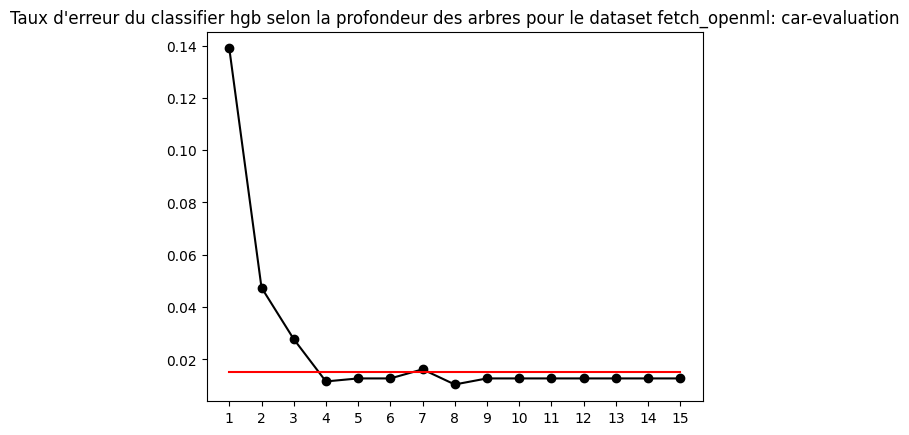

In [86]:
import matplotlib.pyplot as plt
plt.plot(depths, erreurs_hgb, '-o', c='black')
plt.plot([1,15], [0.015,0.015], c='red')
plt.title("Taux d'erreur du classifier hgb selon la profondeur des arbres pour le dataset fetch_openml: car-evaluation")
plt.xticks(np.arange(1,16))
plt.show()

Il semble que le meilleur résultat soit de sélectionner une profondeur d'arbres d'environ 8, ce qui donne un taux d'erreur d'environ 1%.

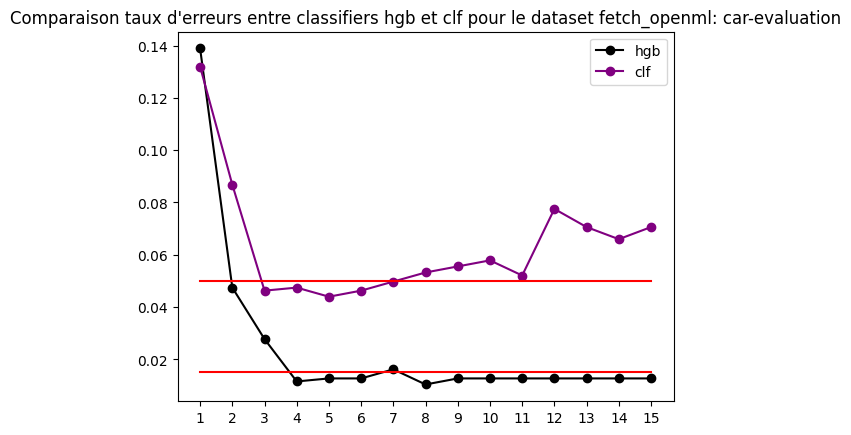

In [88]:
import matplotlib.pyplot as plt
plt.plot(depths, erreurs_hgb, '-o', label="hgb", c='black')
plt.plot(depths, erreurs, '-o', label="clf", c='purple')
plt.plot([1,15], [0.05,0.05], c='red')
plt.plot([1,15], [0.015,0.015], c='red')
plt.xticks(np.arange(1,16))
plt.title("Comparaison taux d'erreurs entre classifiers hgb et clf pour le dataset fetch_openml: car-evaluation")
plt.legend()
plt.show()

In [124]:
from sklearn.datasets import load_breast_cancer

In [125]:
X, y = load_breast_cancer(return_X_y=True)

In [126]:
X_train, X_test, Y_train, Y_test = train_test_split(X,y, 
                                    test_size=0.5, stratify=y)

In [127]:
erreurs_ada = []
depths = np.arange(1,16)
max_depth = 15
for depth in range(1,max_depth+1):
    clf = AdaBoostClassifier(DecisionTreeClassifier(max_depth=depth), 
                            n_estimators=100)
    clf.fit(X_train, Y_train)
    score_test_clf = accuracy_score(Y_test, clf.predict(X_test))
    erreurs_ada.append(1-score_test_clf)

In [128]:
erreurs_hgb = []
depths = np.arange(1,16)
max_depth = 15
for depth in range(1,max_depth+1):
    hgb = HistGradientBoostingClassifier(max_iter=100, max_depth=depth)
    hgb.fit(X_train, Y_train)
    score_test_hgb = accuracy_score(Y_test, hgb.predict(X_test))
    erreurs_hgb.append(1-score_test_hgb)

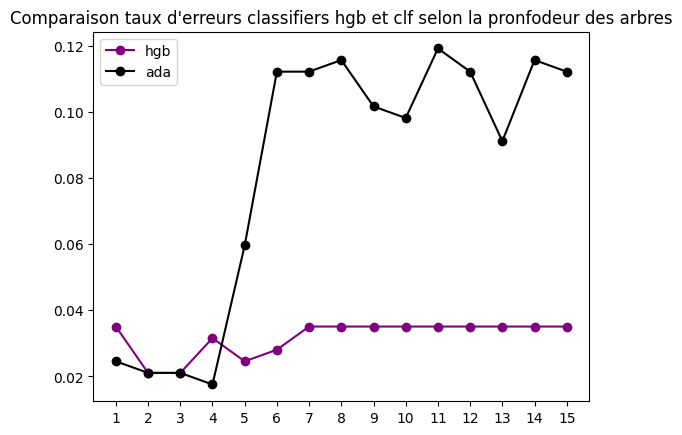

In [132]:
plt.plot(depths, erreurs_hgb, '-o', label="hgb", c='purple')
plt.plot(depths, erreurs_ada, '-o', label="ada", c='black')
plt.xticks(np.arange(1,16))
plt.title("Comparaison taux d'erreurs classifiers hgb et clf selon la pronfodeur des arbres")
plt.legend()
plt.show()

On observe que pour ce dataset, le modèle AdaBoost explose rapidement en erreur lorsque la profondeur des arbres augmente, pour atteindre un taux d'erreur d'environ 10%. Donc ce modèle semble très sensible au bruit et à sur-apprendre rapidement.  

Le modèle hgb quant à lui est ultra stable à partir d'une certaine profondeur, le modèle est plus robuste et donne un bien meilleur score (d'environ 96%).

En conclusion, hgb surclasse clairement AdaBoost sur ce dataset.
AdaBoost devient instable et surapprend, alors qu’hgb reste stable et performant.

## 3 - Gradient Boosting: learning rate versus number of trees

Enfin, on s'interesse exclusivement au modèle de Gradient Boosting et à l'évolution de ses performances de prédiction en fonction du nombre d'arbres.

In [134]:
from sklearn.datasets import fetch_california_housing
X,y = fetch_california_housing(return_X_y=True, as_frame=True)
n_samples, n_features = X.shape
print(f"number of samples: {n_samples}, number of features: {n_features}")

number of samples: 20640, number of features: 8


In [136]:
X_train, X_test, Y_train, Y_test = train_test_split(X,y, 
                                    test_size=0.5)

In [161]:
# affiche tous les paramètres de scoring possible
from sklearn.metrics import get_scorer_names
# get_scorer_names()

Learning rate: 0.1


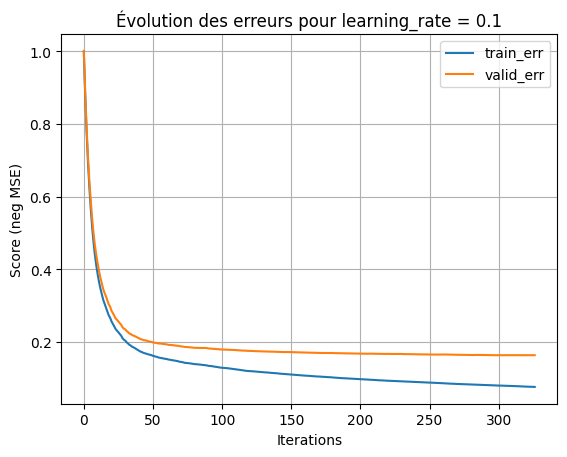

Learning rate: 0.01


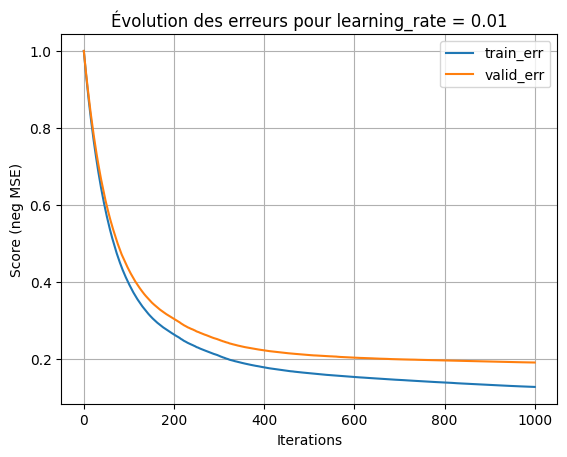

Learning rate: 0.001


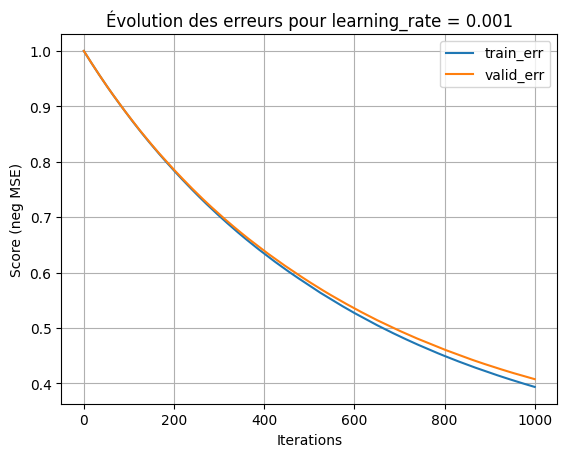

In [165]:
from sklearn.ensemble import HistGradientBoostingRegressor
lr_range = [0.1, 0.01, 0.001]
train_err = []
valid_err = []
for lr in lr_range:
    print(f"Learning rate: {lr}")
    gmb = HistGradientBoostingRegressor(max_iter=1000, max_depth=5, learning_rate=lr, early_stopping=True, validation_fraction=0.2,
                                        scoring="r2")
    gmb.fit(X_train,Y_train)
    train_err = 1 - gmb.train_score_
    valid_err = 1 - gmb.validation_score_

    iterations = range(len(train_err))

    plt.plot(iterations, train_err, label="train_err")
    plt.plot(iterations, valid_err, label="valid_err")
    plt.title(f"Évolution des erreurs pour learning_rate = {lr}")
    plt.xlabel("Iterations")
    plt.ylabel("Score (neg MSE)")
    plt.legend()
    plt.grid(True)
    plt.show()

Conclusion:  
Les trois courbes montrent l’effet du learning rate sur la vitesse et la qualité d’apprentissage du modèle:  

learning rate = 0.1:
- Convergence très rapide
- Meilleures performances finales
- Courbes train/validation proches : peu d’overfitting

learning rate = 0.01: 
- Convergence plus lente
- Performances légèrement inférieures
- Modèle stable et sans overfitting

learning rate = 0.001:
- Convergence très lente
- Performances nettement plus faibles

Le meilleur modèle a pour paramètre un learning rate de 0.1.